# OpenMeteo Weather Data Analysis - Extended Dataset (2023-2025)

Analysis of weather data from OpenMeteo for the period June 2023 to June 2025.

**Version**: V4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
data_path = '/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openmeteo_processed_20230601_to_20250630.csv'
print(f"Loading OpenMeteo data from: {data_path}")

df = pd.read_csv(data_path)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Loading OpenMeteo data from: /Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openmeteo_processed_20230601_to_20250630.csv
Dataset shape: 547,920 rows × 41 columns
Date range: 2023-06-01 00:00:00+00:00 to 2025-06-30 23:00:00+00:00
Memory usage: 261.8 MB


## 1. Dataset Overview

In [3]:
print("Dataset Info:")
print("="*60)
print(f"Total records: {len(df):,}")
print(f"Unique hexagons (res8): {df['h3_index_res8'].nunique():,}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype}")

Dataset Info:
Total records: 547,920
Unique hexagons (res8): 30
Date range: 2023-06-01 00:00:00+00:00 to 2025-06-30 23:00:00+00:00

Columns (41):
  - timestamp: datetime64[ns, UTC]
  - h3_index_res8: object
  - cloud_cover_pct_mean: float64
  - cloud_cover_pct_std: float64
  - cloud_cover_pct_min: float64
  - cloud_cover_pct_max: float64
  - cloud_cover_pct_count: int64
  - dew_point_c_mean: float64
  - dew_point_c_std: float64
  - dew_point_c_min: float64
  - dew_point_c_max: float64
  - dew_point_c_count: int64
  - humidity_pct_mean: float64
  - humidity_pct_std: float64
  - humidity_pct_min: float64
  - humidity_pct_max: float64
  - humidity_pct_count: int64
  - precipitation_mm_mean: float64
  - precipitation_mm_std: float64
  - precipitation_mm_min: float64
  - precipitation_mm_max: float64
  - precipitation_mm_count: int64
  - pressure_hpa_mean: float64
  - pressure_hpa_std: float64
  - pressure_hpa_min: float64
  - pressure_hpa_max: float64
  - pressure_hpa_count: int64
  - sola

In [4]:
print("First 10 rows:")
display(df.head(10))

print("\nLast 10 rows:")
display(df.tail(10))

First 10 rows:


,timestamp,h3_index_res8,cloud_cover_pct_mean,cloud_cover_pct_std,cloud_cover_pct_min,cloud_cover_pct_max,cloud_cover_pct_count,dew_point_c_mean,dew_point_c_std,dew_point_c_min,dew_point_c_max,dew_point_c_count,humidity_pct_mean,humidity_pct_std,humidity_pct_min,humidity_pct_max,humidity_pct_count,precipitation_mm_mean,precipitation_mm_std,precipitation_mm_min,precipitation_mm_max,precipitation_mm_count,pressure_hpa_mean,pressure_hpa_std,pressure_hpa_min,pressure_hpa_max,pressure_hpa_count,solar_radiation_wm2_mean,solar_radiation_wm2_std,solar_radiation_wm2_min,solar_radiation_wm2_max,solar_radiation_wm2_count,temperature_c_mean,temperature_c_std,temperature_c_min,temperature_c_max,temperature_c_count,h3_lat_res8,h3_lon_res8,data_source,country
0,2023-06-01 00:00:00+00:00,882e0800ddfffff,75.00,NaN,75.00,75.00,1,12.60,NaN,12.60,12.60,1,93.00,NaN,93.00,93.00,1,0.00,NaN,0.00,0.00,1,1013.00,NaN,1013.00,1013.00,1,0.00,NaN,0.00,0.00,1,13.70,NaN,13.70,13.70,1,39.72,140.10,openmeteo,JP
1,2023-06-01 00:00:00+00:00,882e1b56b1fffff,9.00,NaN,9.00,9.00,1,4.70,NaN,4.70,4.70,1,85.00,NaN,85.00,85.00,1,0.00,NaN,0.00,0.00,1,1007.80,NaN,1007.80,1007.80,1,0.00,NaN,0.00,0.00,1,7.00,NaN,7.00,7.00,1,43.07,141.35,openmeteo,JP
2,2023-06-01 00:00:00+00:00,882e2b4519fffff,0.00,NaN,0.00,0.00,1,6.60,NaN,6.60,6.60,1,75.00,NaN,75.00,75.00,1,0.00,NaN,0.00,0.00,1,1008.00,NaN,1008.00,1008.00,1,0.00,NaN,0.00,0.00,1,10.80,NaN,10.80,10.80,1,38.27,140.87,openmeteo,JP
3,2023-06-01 00:00:00+00:00,882e44d213fffff,99.00,NaN,99.00,99.00,1,10.60,NaN,10.60,10.60,1,80.00,NaN,80.00,80.00,1,0.00,NaN,0.00,0.00,1,1009.00,NaN,1009.00,1009.00,1,0.00,NaN,0.00,0.00,1,13.90,NaN,13.90,13.90,1,36.56,136.66,openmeteo,JP
4,2023-06-01 00:00:00+00:00,882e604c83fffff,100.00,NaN,100.00,100.00,1,15.40,NaN,15.40,15.40,1,97.00,NaN,97.00,97.00,1,0.00,NaN,0.00,0.00,1,1011.20,NaN,1011.20,1011.20,1,0.00,NaN,0.00,0.00,1,15.90,NaN,15.90,15.90,1,35.43,136.76,openmeteo,JP
5,2023-06-01 00:00:00+00:00,882e605439fffff,59.00,NaN,59.00,59.00,1,15.30,NaN,15.30,15.30,1,94.00,NaN,94.00,94.00,1,0.00,NaN,0.00,0.00,1,1010.80,NaN,1010.80,1010.80,1,0.00,NaN,0.00,0.00,1,16.20,NaN,16.20,16.20,1,35.18,136.90,openmeteo,JP
6,2023-06-01 00:00:00+00:00,882e610515fffff,0.00,NaN,0.00,0.00,1,13.80,NaN,13.80,13.80,1,89.00,NaN,89.00,89.00,1,0.00,NaN,0.00,0.00,1,1012.30,NaN,1012.30,1012.30,1,0.00,NaN,0.00,0.00,1,15.60,NaN,15.60,15.60,1,34.69,135.50,openmeteo,JP
7,2023-06-01 00:00:00+00:00,882e611a3bfffff,0.00,NaN,0.00,0.00,1,13.50,NaN,13.50,13.50,1,93.00,NaN,93.00,93.00,1,0.00,NaN,0.00,0.00,1,1005.00,NaN,1005.00,1005.00,1,0.00,NaN,0.00,0.00,1,14.70,NaN,14.70,14.70,1,34.69,135.80,openmeteo,JP
8,2023-06-01 00:00:00+00:00,882e612019fffff,3.00,NaN,3.00,3.00,1,11.10,NaN,11.10,11.10,1,74.00,NaN,74.00,74.00,1,0.00,NaN,0.00,0.00,1,1011.20,NaN,1011.20,1011.20,1,0.00,NaN,0.00,0.00,1,15.70,NaN,15.70,15.70,1,34.69,135.19,openmeteo,JP
9,2023-06-01 00:00:00+00:00,882e61409bfffff,46.00,NaN,46.00,46.00,1,16.10,NaN,16.10,16.10,1,92.00,NaN,92.00,92.00,1,0.00,NaN,0.00,0.00,1,1006.90,NaN,1006.90,1006.90,1,0.00,NaN,0.00,0.00,1,17.40,NaN,17.40,17.40,1,35.01,135.77,openmeteo,JP



Last 10 rows:


,timestamp,h3_index_res8,cloud_cover_pct_mean,cloud_cover_pct_std,cloud_cover_pct_min,cloud_cover_pct_max,cloud_cover_pct_count,dew_point_c_mean,dew_point_c_std,dew_point_c_min,dew_point_c_max,dew_point_c_count,humidity_pct_mean,humidity_pct_std,humidity_pct_min,humidity_pct_max,humidity_pct_count,precipitation_mm_mean,precipitation_mm_std,precipitation_mm_min,precipitation_mm_max,precipitation_mm_count,pressure_hpa_mean,pressure_hpa_std,pressure_hpa_min,pressure_hpa_max,pressure_hpa_count,solar_radiation_wm2_mean,solar_radiation_wm2_std,solar_radiation_wm2_min,solar_radiation_wm2_max,solar_radiation_wm2_count,temperature_c_mean,temperature_c_std,temperature_c_min,temperature_c_max,temperature_c_count,h3_lat_res8,h3_lon_res8,data_source,country
547910,2025-06-30 23:00:00+00:00,882f5aa5a9fffff,26.00,NaN,26.00,26.00,1,23.40,NaN,23.40,23.40,1,80.00,NaN,80.00,80.00,1,0.00,NaN,0.00,0.00,1,1011.80,NaN,1011.80,1011.80,1,0.00,NaN,0.00,0.00,1,27.00,NaN,27.00,27.00,1,35.53,139.70,openmeteo,JP
547911,2025-06-30 23:00:00+00:00,882f5ab92dfffff,23.00,NaN,23.00,23.00,1,23.10,NaN,23.10,23.10,1,84.00,NaN,84.00,84.00,1,0.00,NaN,0.00,0.00,1,1012.70,NaN,1012.70,1012.70,1,0.00,NaN,0.00,0.00,1,26.00,NaN,26.00,26.00,1,35.61,140.11,openmeteo,JP
547912,2025-06-30 23:00:00+00:00,882f5bc0bdfffff,21.00,NaN,21.00,21.00,1,23.10,NaN,23.10,23.10,1,81.00,NaN,81.00,81.00,1,0.00,NaN,0.00,0.00,1,1001.80,NaN,1001.80,1001.80,1,0.00,NaN,0.00,0.00,1,26.50,NaN,26.50,26.50,1,35.55,139.36,openmeteo,JP
547913,2025-06-30 23:00:00+00:00,882f5bd32dfffff,26.00,NaN,26.00,26.00,1,23.50,NaN,23.50,23.50,1,81.00,NaN,81.00,81.00,1,0.00,NaN,0.00,0.00,1,1012.20,NaN,1012.20,1012.20,1,0.00,NaN,0.00,0.00,1,26.90,NaN,26.90,26.90,1,35.44,139.64,openmeteo,JP
547914,2025-06-30 23:00:00+00:00,8830d9ac63fffff,11.00,NaN,11.00,11.00,1,21.60,NaN,21.60,21.60,1,67.00,NaN,67.00,67.00,1,0.00,NaN,0.00,0.00,1,1012.70,NaN,1012.70,1012.70,1,0.00,NaN,0.00,0.00,1,28.20,NaN,28.20,28.20,1,33.59,130.41,openmeteo,JP
547915,2025-06-30 23:00:00+00:00,8830dbaad1fffff,3.00,NaN,3.00,3.00,1,24.80,NaN,24.80,24.80,1,95.00,NaN,95.00,95.00,1,0.00,NaN,0.00,0.00,1,1011.90,NaN,1011.90,1011.90,1,0.00,NaN,0.00,0.00,1,25.70,NaN,25.70,25.70,1,32.75,129.88,openmeteo,JP
547916,2025-06-30 23:00:00+00:00,884b609b35fffff,9.00,NaN,9.00,9.00,1,25.80,NaN,25.80,25.80,1,91.00,NaN,91.00,91.00,1,0.00,NaN,0.00,0.00,1,1012.80,NaN,1012.80,1012.80,1,0.00,NaN,0.00,0.00,1,27.40,NaN,27.40,27.40,1,33.24,131.61,openmeteo,JP
547917,2025-06-30 23:00:00+00:00,884b61b73bfffff,1.00,NaN,1.00,1.00,1,24.60,NaN,24.60,24.60,1,93.00,NaN,93.00,93.00,1,0.00,NaN,0.00,0.00,1,1012.80,NaN,1012.80,1012.80,1,0.00,NaN,0.00,0.00,1,25.70,NaN,25.70,25.70,1,33.56,133.53,openmeteo,JP
547918,2025-06-30 23:00:00+00:00,884b6254a3fffff,9.00,NaN,9.00,9.00,1,24.70,NaN,24.70,24.70,1,96.00,NaN,96.00,96.00,1,0.00,NaN,0.00,0.00,1,1012.40,NaN,1012.40,1012.40,1,0.00,NaN,0.00,0.00,1,25.40,NaN,25.40,25.40,1,31.91,131.42,openmeteo,JP
547919,2025-06-30 23:00:00+00:00,884b661181fffff,12.00,NaN,12.00,12.00,1,25.00,NaN,25.00,25.00,1,86.00,NaN,86.00,86.00,1,0.00,NaN,0.00,0.00,1,1011.90,NaN,1011.90,1011.90,1,0.00,NaN,0.00,0.00,1,27.60,NaN,27.60,27.60,1,32.80,130.71,openmeteo,JP


## 2. Temporal Coverage Analysis

In [5]:
df['date'] = df['timestamp'].dt.date
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month

all_dates = pd.date_range('2023-06-01', '2025-06-30', freq='D').date
existing_dates = set(df['date'].unique())
missing_dates = sorted(set(all_dates) - existing_dates)

print(f"Temporal Coverage Analysis:")
print("="*60)
print(f"Expected days: {len(all_dates)}")
print(f"Days with data: {len(existing_dates)}")
print(f"Missing days: {len(missing_dates)}")
print(f"Coverage: {len(existing_dates)/len(all_dates)*100:.1f}%")

if len(existing_dates) == len(all_dates):
    print("\n✓ COMPLETE COVERAGE CONFIRMED!")
else:
    print(f"\n⚠ Missing {len(missing_dates)} days")

print("\nYearly coverage:")
yearly_counts = df.groupby('year').size()
for year in [2023, 2024, 2025]:
    count = yearly_counts.get(year, 0)
    print(f"  {year}: {count:,} records")

print("\nMonthly coverage by year:")
monthly_counts = df.groupby([df['timestamp'].dt.year, df['timestamp'].dt.month]).size()
for year in [2023, 2024, 2025]:
    print(f"\n{year}:")
    for month in range(1, 13):
        if year == 2023 and month < 6:
            continue
        if year == 2025 and month > 6:
            break
        count = monthly_counts.get((year, month), 0)
        month_name = pd.Timestamp(f'{year}-{month:02d}-01').strftime('%B')
        print(f"  {month_name:10s}: {count:8,} records")

Temporal Coverage Analysis:
Expected days: 761
Days with data: 761
Missing days: 0
Coverage: 100.0%

✓ COMPLETE COVERAGE CONFIRMED!

Yearly coverage:
  2023: 154,080 records
  2024: 263,520 records
  2025: 130,320 records

Monthly coverage by year:

2023:
  June      :   21,600 records
  July      :   22,320 records
  August    :   22,320 records
  September :   21,600 records
  October   :   22,320 records
  November  :   21,600 records
  December  :   22,320 records

2024:
  January   :   22,320 records
  February  :   20,880 records
  March     :   22,320 records
  April     :   21,600 records
  May       :   22,320 records
  June      :   21,600 records
  July      :   22,320 records
  August    :   22,320 records
  September :   21,600 records
  October   :   22,320 records
  November  :   21,600 records
  December  :   22,320 records

2025:
  January   :   22,320 records
  February  :   20,160 records
  March     :   22,320 records
  April     :   21,600 records
  May       :   2

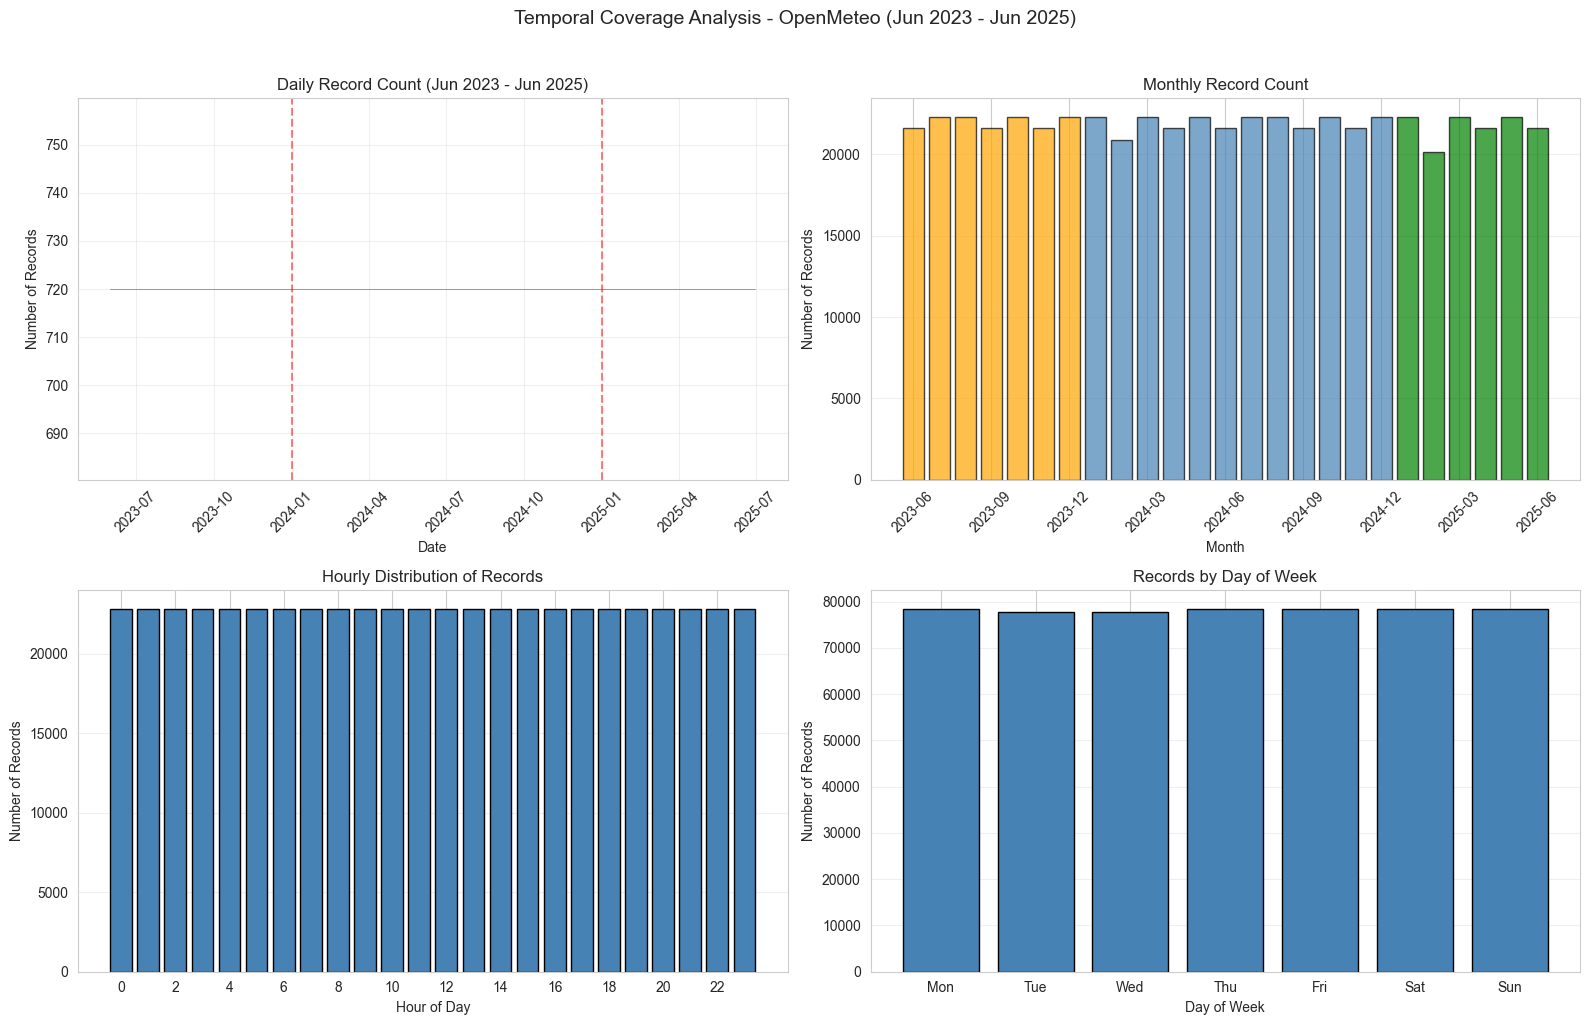

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

daily_counts = df.groupby('date').size().reindex(all_dates, fill_value=0)
axes[0, 0].plot(daily_counts.index, daily_counts.values, linewidth=0.5, color='steelblue')
axes[0, 0].set_title('Daily Record Count (Jun 2023 - Jun 2025)', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

for year in [2024, 2025]:
    year_start = pd.Timestamp(f'{year}-01-01')
    axes[0, 0].axvline(x=year_start, color='red', linestyle='--', alpha=0.5)

monthly_counts_plot = df.groupby(df['timestamp'].dt.to_period('M')).size()
axes[0, 1].bar(range(len(monthly_counts_plot)), monthly_counts_plot.values,
               color=['orange' if '2023' in str(idx) else 'steelblue' if '2024' in str(idx) else 'green'
                      for idx in monthly_counts_plot.index],
               edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Monthly Record Count', fontsize=12)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Number of Records')
axes[0, 1].set_xticks(range(0, len(monthly_counts_plot), 3))
axes[0, 1].set_xticklabels([str(idx) for idx in monthly_counts_plot.index][::3], rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

hourly_counts = df.groupby(df['timestamp'].dt.hour).size()
axes[1, 0].bar(hourly_counts.index, hourly_counts.values, color='steelblue', edgecolor='black')
axes[1, 0].set_title('Hourly Distribution of Records', fontsize=12)
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Number of Records')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3, axis='y')

weekday_counts = df.groupby(df['timestamp'].dt.dayofweek).size()
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 1].bar(range(7), weekday_counts.reindex(range(7), fill_value=0).values,
               color='steelblue', edgecolor='black')
axes[1, 1].set_title('Records by Day of Week', fontsize=12)
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Number of Records')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(weekday_names)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Temporal Coverage Analysis - OpenMeteo (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Missing Data Analysis

In [7]:
weather_cols = [col for col in df.columns if any(pattern in col for pattern in 
                ['temperature', 'humidity', 'precipitation', 'pressure', 'cloud', 'dew', 'solar', 'wind']) 
                and 'mean' in col and col != 'timestamp']

if not weather_cols:
    weather_cols = [col for col in df.columns if 'mean' in col and col not in ['timestamp', 'h3_index_res8', 'h3_lat_res8', 'h3_lon_res8', 'data_source', 'country']]

missing_stats = pd.DataFrame({
    'Missing Count': df[weather_cols].isnull().sum(),
    'Missing %': (df[weather_cols].isnull().sum() / len(df) * 100).round(2),
    'Available Count': df[weather_cols].notnull().sum(),
    'Available %': (df[weather_cols].notnull().sum() / len(df) * 100).round(2)
})

print("Missing Data Summary:")
print("="*60)
display(missing_stats)

Missing Data Summary:


,Missing Count,Missing %,Available Count,Available %
cloud_cover_pct_mean,0,0.00,547920,100.00
dew_point_c_mean,0,0.00,547920,100.00
humidity_pct_mean,0,0.00,547920,100.00
precipitation_mm_mean,0,0.00,547920,100.00
pressure_hpa_mean,0,0.00,547920,100.00
solar_radiation_wm2_mean,696,0.13,547224,99.87
temperature_c_mean,0,0.00,547920,100.00


## 4. Feature Distributions

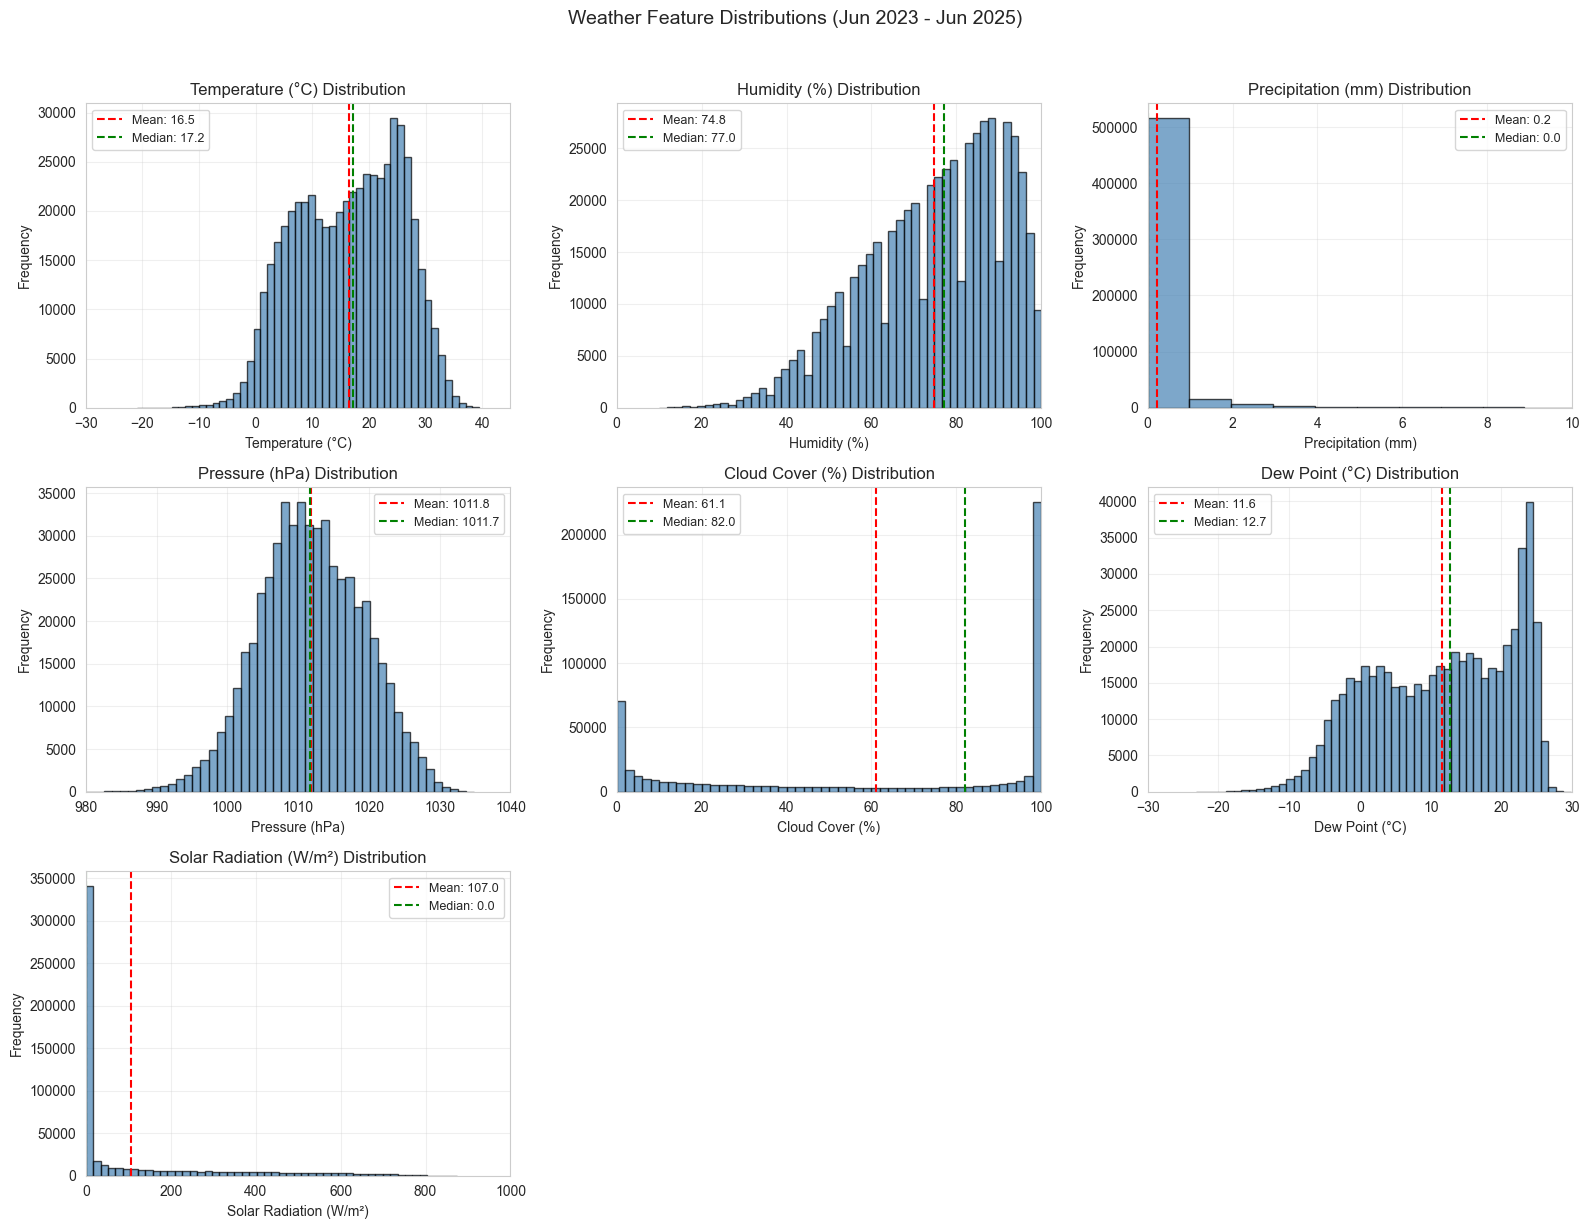

In [8]:
temp_col = [col for col in df.columns if 'temperature' in col.lower() and 'mean' in col][0] if any('temperature' in col.lower() for col in df.columns) else None
humid_col = [col for col in df.columns if 'humidity' in col.lower() and 'mean' in col][0] if any('humidity' in col.lower() for col in df.columns) else None
precip_col = [col for col in df.columns if 'precipitation' in col.lower() and 'mean' in col][0] if any('precipitation' in col.lower() for col in df.columns) else None
press_col = [col for col in df.columns if 'pressure' in col.lower() and 'mean' in col][0] if any('pressure' in col.lower() for col in df.columns) else None
cloud_col = [col for col in df.columns if 'cloud' in col.lower() and 'mean' in col][0] if any('cloud' in col.lower() for col in df.columns) else None
dew_col = [col for col in df.columns if 'dew' in col.lower() and 'mean' in col][0] if any('dew' in col.lower() for col in df.columns) else None
solar_col = [col for col in df.columns if 'solar' in col.lower() and 'mean' in col][0] if any('solar' in col.lower() for col in df.columns) else None

features_to_plot = []
if temp_col: features_to_plot.append((temp_col, 'Temperature (°C)', (-30, 45)))
if humid_col: features_to_plot.append((humid_col, 'Humidity (%)', (0, 100)))
if precip_col: features_to_plot.append((precip_col, 'Precipitation (mm)', (0, 10)))
if press_col: features_to_plot.append((press_col, 'Pressure (hPa)', (980, 1040)))
if cloud_col: features_to_plot.append((cloud_col, 'Cloud Cover (%)', (0, 100)))
if dew_col: features_to_plot.append((dew_col, 'Dew Point (°C)', (-30, 30)))
if solar_col: features_to_plot.append((solar_col, 'Solar Radiation (W/m²)', (0, 1000)))

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, (feature, label, xlim) in enumerate(features_to_plot):
    if feature in df.columns:
        data = df[feature].dropna()
        data = data[np.isfinite(data)]
        
        if len(data) > 0:
            axes[idx].hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
            axes[idx].set_xlabel(label)
            axes[idx].set_ylabel('Frequency')
            axes[idx].set_title(f'{label} Distribution')
            if xlim:
                axes[idx].set_xlim(xlim)
            
            mean_val = data.mean()
            median_val = data.median()
            axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
            axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
            axes[idx].legend(loc='best', fontsize=9)
            axes[idx].grid(True, alpha=0.3)

for idx in range(len(features_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Weather Feature Distributions (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Geographic Coverage

In [9]:
hex_locations = df[['h3_index_res8', 'h3_lat_res8', 'h3_lon_res8']].drop_duplicates()
print(f"Geographic Coverage:")
print("="*60)
print(f"Unique hexagons: {len(hex_locations):,}")
print(f"Latitude range: {hex_locations['h3_lat_res8'].min():.2f} to {hex_locations['h3_lat_res8'].max():.2f}")
print(f"Longitude range: {hex_locations['h3_lon_res8'].min():.2f} to {hex_locations['h3_lon_res8'].max():.2f}")

hex_data_counts = df.groupby('h3_index_res8').agg({
    'timestamp': ['count', 'min', 'max']
}).reset_index()
hex_data_counts.columns = ['h3_index_res8', 'record_count', 'first_date', 'last_date']
hex_with_counts = hex_locations.merge(hex_data_counts, on='h3_index_res8')

print(f"\nRecords per hexagon:")
print(f"  Mean: {hex_with_counts['record_count'].mean():.0f}")
print(f"  Median: {hex_with_counts['record_count'].median():.0f}")
print(f"  Min: {hex_with_counts['record_count'].min()}")
print(f"  Max: {hex_with_counts['record_count'].max()}")

expected_records = len(all_dates) * 24
completeness = hex_with_counts['record_count'] / expected_records * 100
print(f"\nData completeness per hexagon:")
print(f"  Mean: {completeness.mean():.1f}%")
print(f"  Median: {completeness.median():.1f}%")

Geographic Coverage:
Unique hexagons: 30
Latitude range: 31.91 to 43.07
Longitude range: 129.88 to 141.35

Records per hexagon:
  Mean: 18264
  Median: 18264
  Min: 18264
  Max: 18264

Data completeness per hexagon:
  Mean: 100.0%
  Median: 100.0%


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

scatter = axes[0, 0].scatter(hex_with_counts['h3_lon_res8'],
                         hex_with_counts['h3_lat_res8'],
                         c=hex_with_counts['record_count'],
                         cmap='YlOrRd', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')
axes[0, 0].set_title('Weather Station Hexagon Locations with Data Density')
plt.colorbar(scatter, ax=axes[0, 0], label='Record Count')

axes[0, 1].hist(hex_with_counts['record_count'], bins=30, edgecolor='black', color='steelblue')
axes[0, 1].set_xlabel('Records per Hexagon')
axes[0, 1].set_ylabel('Number of Hexagons')
axes[0, 1].set_title('Distribution of Records per Hexagon')
axes[0, 1].axvline(expected_records, color='red', linestyle='--',
                label=f'Expected (full period): {expected_records}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

if temp_col:
    location_temp = df.groupby(['h3_index_res8', 'h3_lat_res8', 'h3_lon_res8'])[temp_col].mean().reset_index()
    scatter2 = axes[0, 2].scatter(location_temp['h3_lon_res8'],
                                  location_temp['h3_lat_res8'],
                                  c=location_temp[temp_col],
                                  cmap='RdBu_r', s=50, alpha=0.8,
                                  edgecolors='black', linewidth=0.5)
    axes[0, 2].set_xlabel('Longitude')
    axes[0, 2].set_ylabel('Latitude')
    axes[0, 2].set_title('Mean Temperature by Location')
    plt.colorbar(scatter2, ax=axes[0, 2], label='Temperature (°C)')

if precip_col:
    location_precip = df.groupby(['h3_index_res8', 'h3_lat_res8', 'h3_lon_res8'])[precip_col].sum().reset_index()
    scatter3 = axes[1, 0].scatter(location_precip['h3_lon_res8'],
                                  location_precip['h3_lat_res8'],
                                  c=location_precip[precip_col],
                                  cmap='Blues', s=50, alpha=0.8,
                                  edgecolors='black', linewidth=0.5)
    axes[1, 0].set_xlabel('Longitude')
    axes[1, 0].set_ylabel('Latitude')
    axes[1, 0].set_title('Total Precipitation by Location')
    plt.colorbar(scatter3, ax=axes[1, 0], label='Precipitation (mm)')

if humid_col:
    location_humid = df.groupby(['h3_index_res8', 'h3_lat_res8', 'h3_lon_res8'])[humid_col].mean().reset_index()
    scatter4 = axes[1, 1].scatter(location_humid['h3_lon_res8'],
                                  location_humid['h3_lat_res8'],
                                  c=location_humid[humid_col],
                                  cmap='YlGn', s=50, alpha=0.8,
                                  edgecolors='black', linewidth=0.5)
    axes[1, 1].set_xlabel('Longitude')
    axes[1, 1].set_ylabel('Latitude')
    axes[1, 1].set_title('Mean Humidity by Location')
    plt.colorbar(scatter4, ax=axes[1, 1], label='Humidity (%)')

if solar_col:
    location_solar = df.groupby(['h3_index_res8', 'h3_lat_res8', 'h3_lon_res8'])[solar_col].mean().reset_index()
    scatter5 = axes[1, 2].scatter(location_solar['h3_lon_res8'],
                                  location_solar['h3_lat_res8'],
                                  c=location_solar[solar_col],
                                  cmap='YlOrBr', s=50, alpha=0.8,
                                  edgecolors='black', linewidth=0.5)
    axes[1, 2].set_xlabel('Longitude')
    axes[1, 2].set_ylabel('Latitude')
    axes[1, 2].set_title('Mean Solar Radiation by Location')
    plt.colorbar(scatter5, ax=axes[1, 2], label='Solar Radiation (W/m²)')

plt.suptitle('Geographic Distribution of Weather Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print("\nGeographic Climate Zones Analysis:")
print("="*60)

if temp_col and precip_col:
    location_climate = df.groupby(['h3_index_res8', 'h3_lat_res8', 'h3_lon_res8']).agg({
        temp_col: ['mean', 'std'],
        precip_col: ['mean', 'sum'],
        humid_col: 'mean' if humid_col else None
    }).reset_index()
    
    location_climate.columns = ['_'.join(col).strip('_') for col in location_climate.columns.values]
    
    northern_locs = location_climate[location_climate['h3_lat_res8'] > 40]
    central_locs = location_climate[(location_climate['h3_lat_res8'] >= 35) & (location_climate['h3_lat_res8'] <= 40)]
    southern_locs = location_climate[location_climate['h3_lat_res8'] < 35]
    
    print("\nLatitudinal Climate Zones:")
    print(f"  Northern Japan (>40°N): {len(northern_locs)} hexagons")
    if len(northern_locs) > 0 and f'{temp_col}_mean' in location_climate.columns:
        print(f"    Avg Temperature: {northern_locs[f'{temp_col}_mean'].mean():.1f}°C")
        print(f"    Total Precipitation: {northern_locs[f'{precip_col}_sum'].mean():.0f} mm")
    
    print(f"  Central Japan (35-40°N): {len(central_locs)} hexagons")
    if len(central_locs) > 0 and f'{temp_col}_mean' in location_climate.columns:
        print(f"    Avg Temperature: {central_locs[f'{temp_col}_mean'].mean():.1f}°C")
        print(f"    Total Precipitation: {central_locs[f'{precip_col}_sum'].mean():.0f} mm")
    
    print(f"  Southern Japan (<35°N): {len(southern_locs)} hexagons")
    if len(southern_locs) > 0 and f'{temp_col}_mean' in location_climate.columns:
        print(f"    Avg Temperature: {southern_locs[f'{temp_col}_mean'].mean():.1f}°C")
        print(f"    Total Precipitation: {southern_locs[f'{precip_col}_sum'].mean():.0f} mm")
    
    print("\nCoastal vs Inland Analysis:")
    eastern_locs = location_climate[location_climate['h3_lon_res8'] > 138]
    western_locs = location_climate[location_climate['h3_lon_res8'] <= 138]
    
    print(f"  Eastern Regions (>138°E): {len(eastern_locs)} hexagons")
    if len(eastern_locs) > 0 and f'{temp_col}_mean' in location_climate.columns:
        print(f"    Avg Temperature: {eastern_locs[f'{temp_col}_mean'].mean():.1f}°C")
        if humid_col and f'{humid_col}_mean' in location_climate.columns:
            print(f"    Avg Humidity: {eastern_locs[f'{humid_col}_mean'].mean():.1f}%")
    
    print(f"  Western Regions (≤138°E): {len(western_locs)} hexagons")
    if len(western_locs) > 0 and f'{temp_col}_mean' in location_climate.columns:
        print(f"    Avg Temperature: {western_locs[f'{temp_col}_mean'].mean():.1f}°C")
        if humid_col and f'{humid_col}_mean' in location_climate.columns:
            print(f"    Avg Humidity: {western_locs[f'{humid_col}_mean'].mean():.1f}%")
    
    print("\nExtreme Locations:")
    if f'{temp_col}_mean' in location_climate.columns:
        hottest = location_climate.loc[location_climate[f'{temp_col}_mean'].idxmax()]
        coldest = location_climate.loc[location_climate[f'{temp_col}_mean'].idxmin()]
        print(f"  Hottest location: ({hottest['h3_lat_res8']:.2f}°N, {hottest['h3_lon_res8']:.2f}°E)")
        print(f"    Mean temperature: {hottest[f'{temp_col}_mean']:.1f}°C")
        
        print(f"  Coldest location: ({coldest['h3_lat_res8']:.2f}°N, {coldest['h3_lon_res8']:.2f}°E)")
        print(f"    Mean temperature: {coldest[f'{temp_col}_mean']:.1f}°C")
    
    if f'{precip_col}_sum' in location_climate.columns:
        wettest = location_climate.loc[location_climate[f'{precip_col}_sum'].idxmax()]
        driest = location_climate.loc[location_climate[f'{precip_col}_sum'].idxmin()]
        print(f"  Wettest location: ({wettest['h3_lat_res8']:.2f}°N, {wettest['h3_lon_res8']:.2f}°E)")
        print(f"    Total precipitation: {wettest[f'{precip_col}_sum']:.0f} mm")
        
        print(f"  Driest location: ({driest['h3_lat_res8']:.2f}°N, {driest['h3_lon_res8']:.2f}°E)")
        print(f"    Total precipitation: {driest[f'{precip_col}_sum']:.0f} mm")

## 6. Seasonal and Temporal Patterns

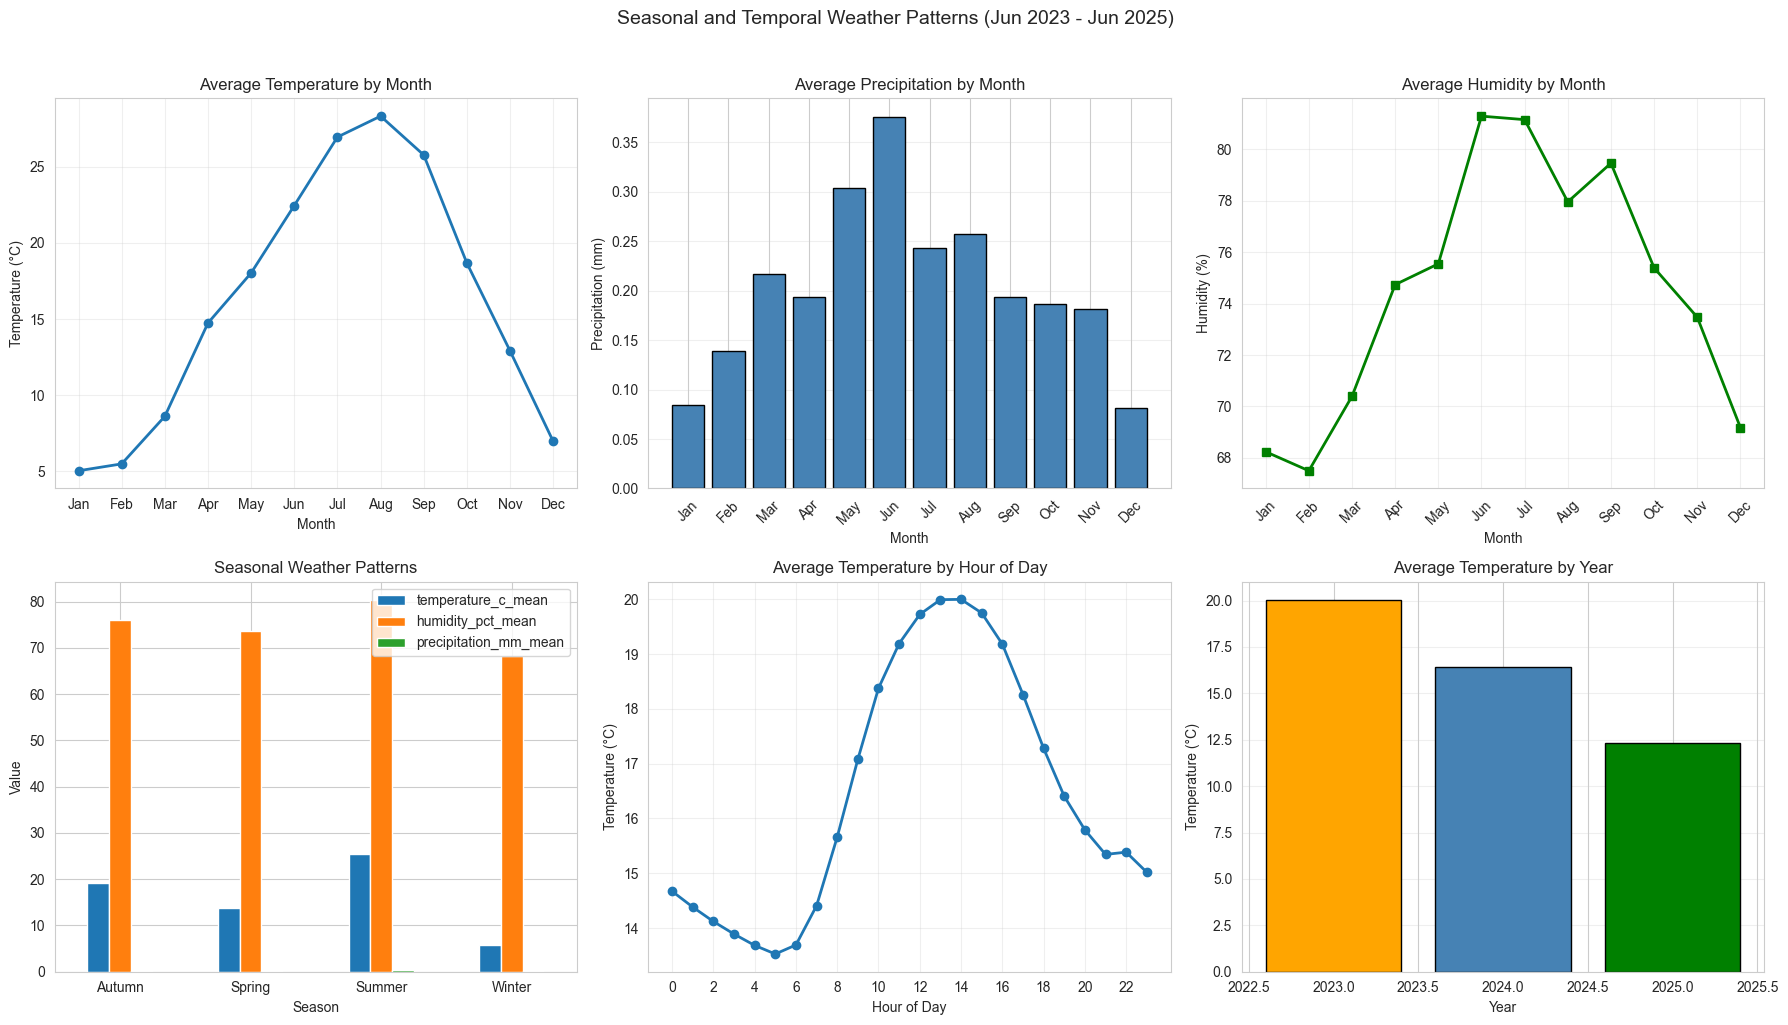

In [11]:
df['hour'] = df['timestamp'].dt.hour
df['season'] = df['month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                 3: 'Spring', 4: 'Spring', 5: 'Spring',
                                 6: 'Summer', 7: 'Summer', 8: 'Summer',
                                 9: 'Autumn', 10: 'Autumn', 11: 'Autumn'})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

if temp_col:
    monthly_temp = df.groupby('month')[temp_col].mean()
    axes[0, 0].plot(monthly_temp.index, monthly_temp.values, marker='o', linewidth=2, markersize=6)
    axes[0, 0].set_xlabel('Month')
    axes[0, 0].set_ylabel('Temperature (°C)')
    axes[0, 0].set_title('Average Temperature by Month')
    axes[0, 0].set_xticks(range(1, 13))
    axes[0, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    axes[0, 0].grid(True, alpha=0.3)

if precip_col:
    monthly_precip = df.groupby('month')[precip_col].mean()
    axes[0, 1].bar(monthly_precip.index, monthly_precip.values, color='steelblue', edgecolor='black')
    axes[0, 1].set_xlabel('Month')
    axes[0, 1].set_ylabel('Precipitation (mm)')
    axes[0, 1].set_title('Average Precipitation by Month')
    axes[0, 1].set_xticks(range(1, 13))
    axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
    axes[0, 1].grid(True, alpha=0.3, axis='y')

if humid_col:
    monthly_humidity = df.groupby('month')[humid_col].mean()
    axes[0, 2].plot(monthly_humidity.index, monthly_humidity.values, marker='s', linewidth=2, color='green', markersize=6)
    axes[0, 2].set_xlabel('Month')
    axes[0, 2].set_ylabel('Humidity (%)')
    axes[0, 2].set_title('Average Humidity by Month')
    axes[0, 2].set_xticks(range(1, 13))
    axes[0, 2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
    axes[0, 2].grid(True, alpha=0.3)

if 'season' in df.columns and df['season'].notna().any():
    plot_cols = []
    if temp_col: plot_cols.append(temp_col)
    if humid_col: plot_cols.append(humid_col)
    if precip_col: plot_cols.append(precip_col)
    
    if plot_cols:
        seasonal_stats = df.groupby('season')[plot_cols].mean()
        seasonal_stats.plot(kind='bar', ax=axes[1, 0])
        axes[1, 0].set_title('Seasonal Weather Patterns', fontsize=12)
        axes[1, 0].set_xlabel('Season')
        axes[1, 0].set_ylabel('Value')
        axes[1, 0].legend(loc='best')
        axes[1, 0].tick_params(axis='x', rotation=0)

if temp_col:
    hourly_temp = df.groupby('hour')[temp_col].mean()
    axes[1, 1].plot(hourly_temp.index, hourly_temp.values, marker='o', linewidth=2)
    axes[1, 1].set_xlabel('Hour of Day')
    axes[1, 1].set_ylabel('Temperature (°C)')
    axes[1, 1].set_title('Average Temperature by Hour of Day')
    axes[1, 1].set_xticks(range(0, 24, 2))
    axes[1, 1].grid(True, alpha=0.3)

if temp_col:
    yearly_temp = df.groupby('year')[temp_col].mean()
    axes[1, 2].bar(yearly_temp.index, yearly_temp.values, color=['orange', 'steelblue', 'green'], edgecolor='black')
    axes[1, 2].set_xlabel('Year')
    axes[1, 2].set_ylabel('Temperature (°C)')
    axes[1, 2].set_title('Average Temperature by Year')
    axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Seasonal and Temporal Weather Patterns (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Yearly Comparison

In [12]:
yearly_stats = df.groupby('year')[weather_cols].agg(['mean', 'std', 'min', 'max'])

print("Yearly Weather Statistics Comparison:")
print("="*60)
for feature in weather_cols:
    print(f"\n{feature.replace('_', ' ').title()}:")
    display(yearly_stats[feature].round(2))

Yearly Weather Statistics Comparison:

Cloud Cover Pct Mean:


,mean,std,min,max
year,,,,
2023,57.80,41.52,0.00,100.00
2024,62.26,41.09,0.00,100.00
2025,62.82,41.43,0.00,100.00



Dew Point C Mean:


,mean,std,min,max
year,,,,
2023,15.48,8.56,-16.60,28.20
2024,11.75,9.75,-18.60,29.80
2025,6.80,9.20,-23.10,27.10



Humidity Pct Mean:


...

,mean,std,min,max
year,,,,
2023,1011.06,7.19,978.00,1034.90
2024,1012.26,7.24,980.10,1033.90
2025,1011.88,7.65,978.00,1032.30



Solar Radiation Wm2 Mean:


,mean,std,min,max
year,,,,
2023,112.43,189.59,0.00,844.00
2024,104.26,185.92,0.00,874.00
2025,106.24,189.38,0.00,865.00



Temperature C Mean:


,mean,std,min,max
year,,,,
2023,20.02,8.27,-12.20,39.50
2024,16.40,9.18,-16.60,38.90
2025,12.35,8.31,-20.90,37.50


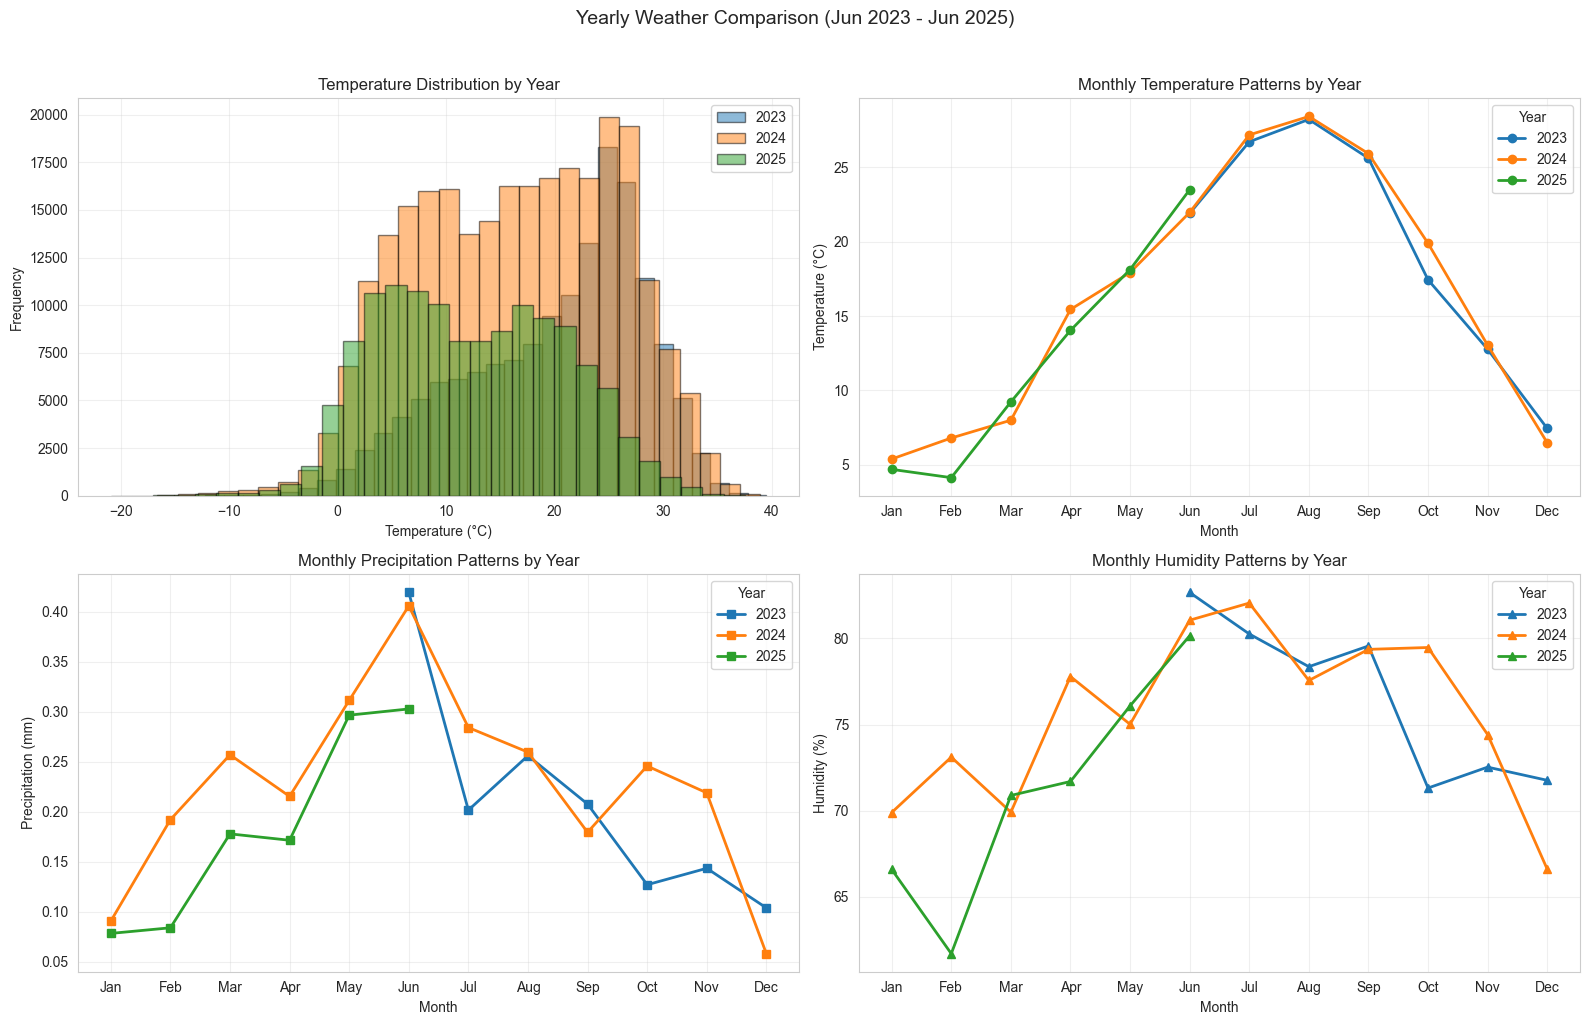

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if temp_col:
    for year in [2023, 2024, 2025]:
        year_data = df[df['year'] == year][temp_col].dropna()
        if len(year_data) > 0:
            axes[0, 0].hist(year_data, bins=30, alpha=0.5, label=str(year), edgecolor='black')
    
    axes[0, 0].set_xlabel('Temperature (°C)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Temperature Distribution by Year')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    yearly_monthly_temp = df.groupby(['year', 'month'])[temp_col].mean().unstack(level=0)
    yearly_monthly_temp.plot(ax=axes[0, 1], marker='o', linewidth=2)
    axes[0, 1].set_xlabel('Month')
    axes[0, 1].set_ylabel('Temperature (°C)')
    axes[0, 1].set_title('Monthly Temperature Patterns by Year')
    axes[0, 1].set_xticks(range(1, 13))
    axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    axes[0, 1].legend(title='Year')
    axes[0, 1].grid(True, alpha=0.3)

if precip_col:
    yearly_monthly_precip = df.groupby(['year', 'month'])[precip_col].mean().unstack(level=0)
    yearly_monthly_precip.plot(ax=axes[1, 0], marker='s', linewidth=2)
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Precipitation (mm)')
    axes[1, 0].set_title('Monthly Precipitation Patterns by Year')
    axes[1, 0].set_xticks(range(1, 13))
    axes[1, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    axes[1, 0].legend(title='Year')
    axes[1, 0].grid(True, alpha=0.3)

if humid_col:
    yearly_monthly_humidity = df.groupby(['year', 'month'])[humid_col].mean().unstack(level=0)
    yearly_monthly_humidity.plot(ax=axes[1, 1], marker='^', linewidth=2)
    axes[1, 1].set_xlabel('Month')
    axes[1, 1].set_ylabel('Humidity (%)')
    axes[1, 1].set_title('Monthly Humidity Patterns by Year')
    axes[1, 1].set_xticks(range(1, 13))
    axes[1, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    axes[1, 1].legend(title='Year')
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Yearly Weather Comparison (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Feature Correlations

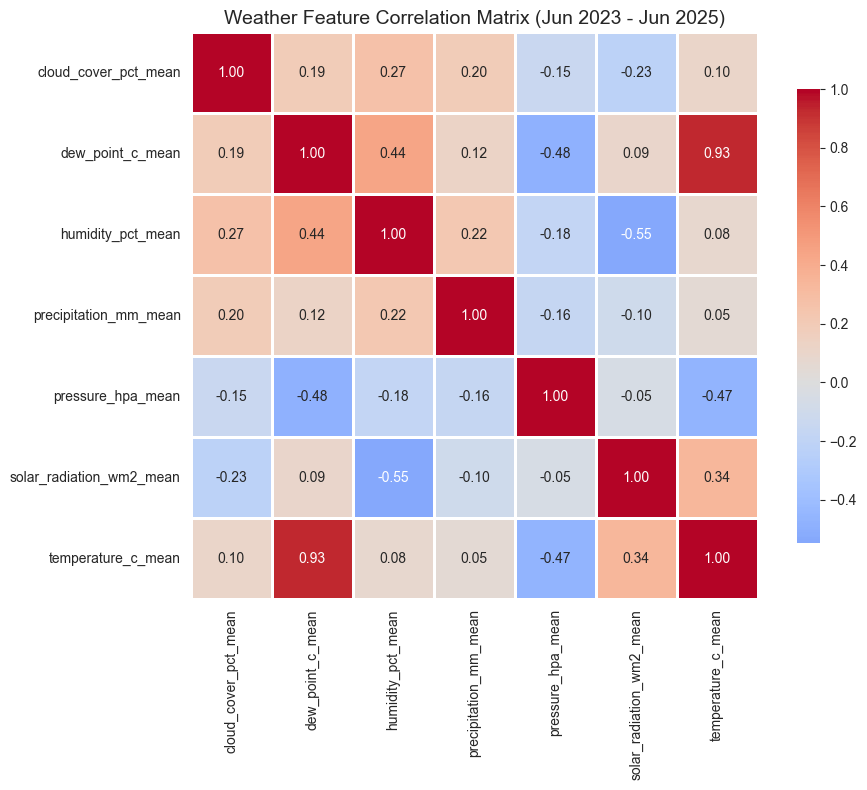


Strongest correlations with temperature:
  dew_point_c_mean: 0.928
  solar_radiation_wm2_mean: 0.339
  pressure_hpa_mean: -0.469


In [14]:
correlation_matrix = df[weather_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Weather Feature Correlation Matrix (Jun 2023 - Jun 2025)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nStrongest correlations with temperature:")
if temp_col and temp_col in correlation_matrix.columns:
    temp_corr = correlation_matrix[temp_col].sort_values(ascending=False)
    for feature, corr in temp_corr.items():
        if feature != temp_col and abs(corr) > 0.3:
            print(f"  {feature}: {corr:.3f}")

## 9. Statistical Summary

In [15]:
print("Statistical Summary of Weather Features (Full Dataset):")
print("="*60)
display(df[weather_cols].describe())

Statistical Summary of Weather Features (Full Dataset):


,cloud_cover_pct_mean,dew_point_c_mean,humidity_pct_mean,precipitation_mm_mean,pressure_hpa_mean,solar_radiation_wm2_mean,temperature_c_mean
count,547920.00,547920.00,547920.00,547920.00,547920.00,547224.00,547920.00
mean,61.14,11.62,74.81,0.21,1011.83,107.03,16.45
std,41.35,9.81,16.15,0.93,7.34,187.82,9.15
min,0.00,-23.10,10.00,0.00,978.00,0.00,-20.90
25%,15.00,3.20,64.00,0.00,1006.80,0.00,8.90
50%,82.00,12.70,77.00,0.00,1011.70,0.00,17.20
75%,100.00,20.80,88.00,0.00,1017.10,137.00,24.20
max,100.00,29.80,100.00,49.30,1034.90,874.00,39.50
